# Initialize

Load packages needed to run script:

In [116]:
%matplotlib widget 
import numpy as np
from matplotlib import pyplot as plt
import plotly.graph_objects as go
from numpy.typing import NDArray
from scipy.optimize import root_scalar
import bfield_calculation
import importlib
importlib.reload(bfield_calculation)
from bfield_calculation import bfield, bfield_inputs, build_M_bfield
import random


Set parameters for use during this run:

In [117]:
n_coils_main = 54*2
z_min, z_max = -3.8, 3.8
R_main = 0.81      # m
B0 = 0.02          # Tesla (20 mT target)

# End rings on each
n_end_each_side = 0
R_end = 0.25       # m (50 cm internal diameter)

l_scale = 1 + 1e-7

fit_min, fit_max = -1.75, 1.75
n_fit_z = 3000
r_fit = np.array([0.0, 0.1, 0.2, 0.330], dtype=float)

# PPM evaluation region
ppm_z_min, ppm_z_max = -1.75, 1.75
ppm_r_max = 0.33

n_ppm_z = 181
n_ppm_r = 61

φ_scale = 10

n_seg = 720

Define constants used throughout the script:

In [118]:
mu0 = 4e-7 * np.pi

## Define functions used throughout the script:

In [119]:
def chebyshev_nodes(n, a, b):
    # n Chebyshev nodes mapped to [a, b], returned sorted ascending.
    k = np.arange(1, n + 1)
    x = np.cos((2*k - 1) * np.pi / (2*n))
    z = 0.5*(a + b) + 0.5*(b - a)*x
    return np.sort(z)

def make_offset(z: NDArray, l_scale: float, d: float) -> NDArray:
    """ Computes the catenary curve of length l_scale*d where d is the displacement when the ends are at equal heights. """
    if l_scale <= 1:
        raise ValueError("Length of material must be larger than displacement.")
    y_disp = np.zeros_like(z)

    a0 = 0.9
    x0 = d/(2*a0)


    def l_resid(x: float):
        return l_scale - np.sinh(x)/x

    sol = root_scalar(l_resid, method = 'secant', x0 = x0, rtol = 1e-10)
    x = sol.root
    a = d/(2*x)
    # print(f"Numerical value of a: {a}")
    y_disp = a*(np.sinh((z + d/2)/(2*a))*np.sinh((z - d/2)/(2*a)))
    

    return y_disp

def φ_from_r(r: NDArray, c: float = 50) -> dict:

    φ_fit = [0]*len(r)
    for i in range(len(r)):
        n_azim = max(1, int(r[i]*c))
        dφ = 2*np.pi/n_azim
        φ_fit[i] = (np.array(np.arange(n_azim) + 0.5)) * dφ

    n_rφ = len(np.concatenate(φ_fit).ravel())

    φ_info = {
        "φ_list": φ_fit,    # List of points to sample, φ_list[i] corresponds with r[i]
        "n_rφ": n_rφ        # Number of points in r-φ plane
    }
    return φ_info


def loop_discretization(R: float, z: float, n: int = 720, offset: float = 0) -> NDArray:
    """ Use Biot-Savart straight line discretization to convert a circular loop centered at (0, offset, z) of radius R into n line segments. 
    
    Parameters
    -----------
    R: float 
        The radius of the loop
    z: float
        The z-coordinate of the loop, where the loop is in the x-y plane
    n: int 
        The number of line segments to break the loop into (default: 720)
    offset: float
        A possible y-shift to the center of the loop

    
    Returns
    --------
        NDArray: An (n+1, 3) array of points, where each pair corresponds to a line segment of the loop
    """
    

    
    # Can adjust as needed to match Mubi's if we determine the arc length method is still applicable. I want to first consider all magnetic effects.
    
    θ, dθ = np.linspace(0, 2*np.pi, n + 1, retstep=True)
    x = R*np.cos(θ)
    y = R*np.sin(θ) + offset
    z = z*np.ones_like(x)
    coil_points = np.array([x, y, z]).transpose()

    return coil_points

def φ_from_r(r: NDArray, c: float = 50) -> dict:

    φ_fit = [0]*len(r)
    for i in range(len(r)):
        n_azim = max(1, int(r[i]*c))
        dφ = 2*np.pi/n_azim
        φ_fit[i] = (np.array(np.arange(n_azim) + 0.5)) * dφ

    n_rφ = len(np.concatenate(φ_fit).ravel())

    φ_info = {
        "φ_list": φ_fit,    # List of points to sample, φ_list[i] corresponds with r[i]
        "n_rφ": n_rφ        # Number of points in r-φ plane
    }
    return φ_info

## Compute

In [120]:
z_main, dz_main = np.linspace(z_min, z_max, n_coils_main, retstep=True)


z_left  = z_min - dz_main * np.arange(n_end_each_side, 0, -1)
z_right = z_max + dz_main * np.arange(1, n_end_each_side + 1)

z_coils = np.concatenate([z_left, z_main, z_right])
R_coils = np.concatenate([
    np.full(n_end_each_side, R_end),
    np.full(n_coils_main, R_main),
    np.full(n_end_each_side, R_end),
])
n_coils = len(z_coils)

print("Total coils:", n_coils)
print("Coil z range:", z_coils[0], "to", z_coils[-1])


Total coils: 108
Coil z range: -3.8 to 3.8


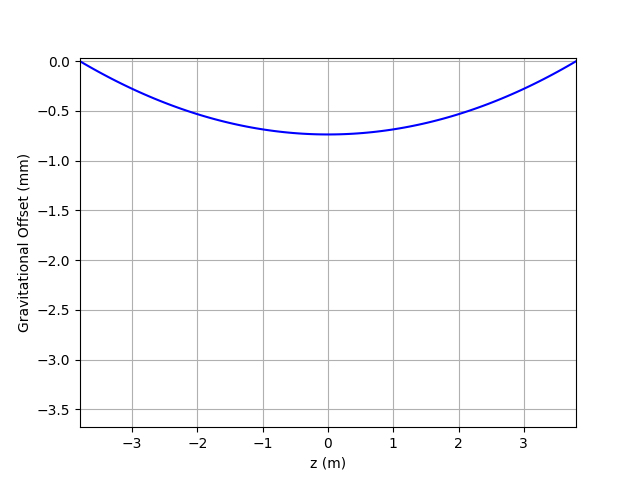

In [121]:
offset = make_offset(z_main, l_scale, 2*max(z_main))
plt.close()
plt.figure()
plt.plot(z_main, 1e3*offset, color = "b")
plt.ylim((5*min(offset)*1e3, abs(min(offset))/20*1e3))
plt.xlim((min(z_main), max(z_main)))
plt.xlabel("z (m)")
plt.ylabel(fr"Gravitational Offset (mm)")
plt.grid()
plt.show()

In [122]:
# FIT region


z_fit = chebyshev_nodes(n_fit_z, fit_min, fit_max)




φ_data = φ_from_r(r_fit, c = φ_scale)
φ_fit = φ_data["φ_list"]
n_rφ = φ_data["n_rφ"]


z_ppm = chebyshev_nodes(n_ppm_z, ppm_z_min, ppm_z_max)
r_ppm = np.linspace(0.0, ppm_r_max, n_ppm_r)


φ_from_r_ppm = φ_from_r(r_ppm, c = φ_scale)
φ_ppm = φ_from_r_ppm["φ_list"]
n_rφ_ppm = φ_from_r_ppm["n_rφ"]



print("Fit grid points:", len(z_fit) * n_rφ)
print("PPM eval points:", len(z_ppm) * n_rφ_ppm)


Fit grid points: 21000
PPM eval points: 16471


# Mubi's scripts

In [123]:
def loop_Bz_numeric(r, z_obs, z0, R, I=1.0, nseg=720):
    dtheta = 2*np.pi / nseg
    theta = (np.arange(nseg) + 0.5) * dtheta

    xs = R*np.cos(theta)
    ys = R*np.sin(theta)
    zs = np.full_like(theta, z0)

    dlx = -R*np.sin(theta) * dtheta
    dly =  R*np.cos(theta) * dtheta

    rx = r - xs
    ry = -ys
    rz = z_obs - zs

    r2 = rx*rx + ry*ry + rz*rz
    r3 = r2 * np.sqrt(r2)

    cz = dlx*ry - dly*rx
    return (mu0/(4*np.pi)) * I * np.sum(cz / r3)

def build_M_Bz(r_list, z_list, z_coils, R_coils, nseg=720):
    npts = len(r_list) * len(z_list)

    M = np.zeros((npts, n_coils), dtype=float)

    row = 0
    for r in r_list:
        for z in z_list:
            for j, (zc, Rc) in enumerate(zip(z_coils, R_coils)):
                M[row, j] = loop_Bz_numeric(r, z, zc, Rc, I=1.0, nseg=nseg)
            row += 1
    return M

In [124]:
print("Building M_fit...")
M_fit = build_M_Bz(r_fit, z_fit, z_coils, R_coils, nseg=n_seg)
b_fit = np.full(M_fit.shape[0], B0, dtype=float)

print("M_fit shape:", M_fit.shape)

Building M_fit...
M_fit shape: (12000, 108)


In [125]:
def weights_z_sigmoid(z, z0=2.5, alpha=0.1, k=20.0):
    return alpha + (1-alpha)/(1+np.exp(k*(np.abs(z)-z0)))


wz = weights_z_sigmoid(z_fit, z0=2.5, alpha=0.1, k=20.0)

p = 2.0
wr = (r_fit / np.max(r_fit))**p
wr[0] = max(wr[0], 0.2)


w_rows = np.concatenate([np.sqrt(wz) * np.sqrt(wr_i) for wr_i in wr])

A = M_fit * w_rows[:, None]
b = b_fit * w_rows

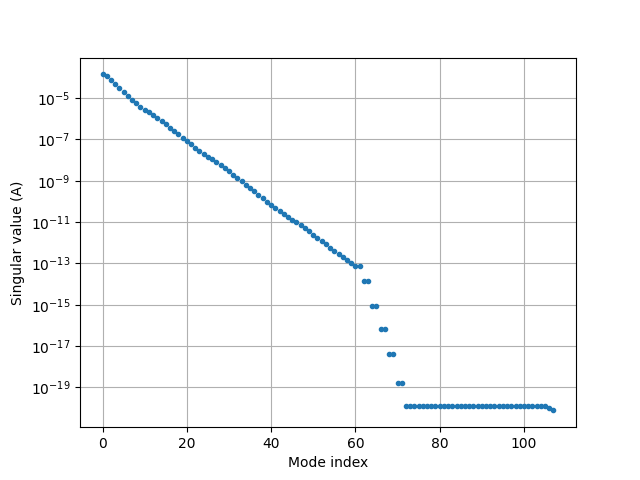

sigma_max: 0.00014061206442214725


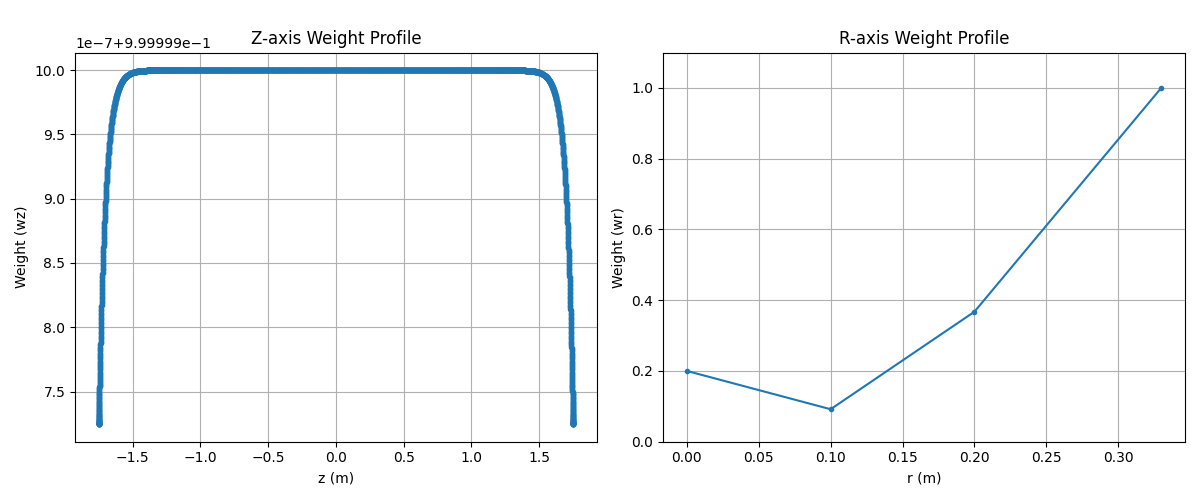

In [126]:
U, s, Vt = np.linalg.svd(A, full_matrices=False)

plt.close()
plt.figure()
plt.semilogy(s, ".")
plt.xlabel("Mode index")
plt.ylabel("Singular value (A)")
plt.grid(True)
plt.show()

sigma_max = s[0]
print("sigma_max:", sigma_max)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(z_fit, wz, ".-")
ax1.set_xlabel("z (m)")
ax1.set_ylabel("Weight (wz)")
ax1.set_title("Z-axis Weight Profile")
ax1.grid(True)

ax2.plot(r_fit, wr, ".-")
ax2.set_xlabel("r (m)")
ax2.set_ylim([0, 1.1])
ax2.set_ylabel("Weight (wr)")
ax2.set_title("R-axis Weight Profile")
ax2.grid(True)

plt.tight_layout()
plt.show()

In [127]:
def diff_matrix_second(n):
    D2 = np.zeros((n-2, n), dtype=float)
    for i in range(n-2):
        D2[i, i]     = 1.0
        D2[i, i+1]   = -2.0
        D2[i, i+2]   = 1.0
    return D2

D2 = diff_matrix_second(n_coils)
D2tD2 = D2.T @ D2

def solve_tikhonov_curvature(A, b, lam, eta, D2tD2):
    AtA = A.T @ A
    Atb = A.T @ b
    R = np.eye(A.shape[1]) + (eta**2) * D2tD2
    return np.linalg.solve(AtA + (lam**2) * R, Atb)

In [128]:
print("Building M_ppm")
M_ppm = build_M_Bz(r_ppm, z_ppm, z_coils, R_coils, nseg=n_seg)
b_ppm = np.full(M_ppm.shape[0], B0, dtype=float)
print("M_ppm shape:", M_ppm.shape)

Building M_ppm
M_ppm shape: (11041, 108)


In [129]:
ETA_OVERRIDE = 30

lam_grid = sigma_max * np.logspace(-7, -2, 16)
eta_grid = (
    np.array([ETA_OVERRIDE], dtype=float)
    if ETA_OVERRIDE is not None
    else np.logspace(-2, 2, 13)
)

In [130]:
obj = np.zeros((len(eta_grid), len(lam_grid)), dtype=float)

best = {
    "obj": np.inf,
    "lam": None,
    "eta": None,
    "I": None,
    "max_ppm": None,
    "max_r": None,
    "max_z": None,
}

nz_ppm = len(z_ppm)

for ie, eta in enumerate(eta_grid):
    for il, lam in enumerate(lam_grid):
        I = solve_tikhonov_curvature(A, b, lam, eta, D2tD2)

        B_pred = M_ppm @ I
        ppm = 1e6 * (B_pred - B0) / B0

        idx = int(np.argmax(np.abs(ppm)))
        max_ppm = float(ppm[idx])

        ir = idx // nz_ppm
        iz = idx % nz_ppm
        r_worst = float(np.linalg.norm(r_ppm[ir]))
        z_worst = float(z_ppm[iz])

        obj_val = abs(max_ppm)
        obj[ie, il] = obj_val

        if obj_val < best["obj"]:
            best.update({
                "obj": obj_val,
                "lam": float(lam),
                "eta": float(eta),
                "I": I.copy(),
                "max_ppm": max_ppm,
                "max_r": r_worst,
                "max_z": z_worst
            })

print("BEST (min max|ppm| on eval region):")
print("  lambda =", best["lam"])
print("  eta    =", best["eta"])
print("  max ppm =", best["max_ppm"], "at r =", best["max_r"], "m, z =", best["max_z"], "m")

BEST (min max|ppm| on eval region):
  lambda = 1.4061206442214724e-11
  eta    = 30.0
  max ppm = -0.12384035099483048 at r = 0.28600000000000003 m, z = 1.7499340996180683 m


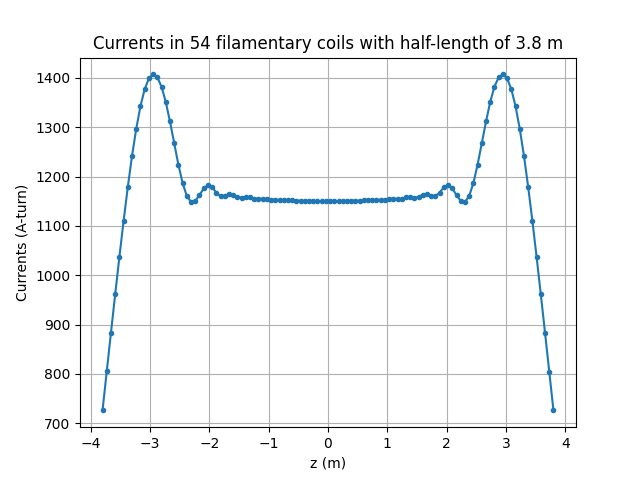

In [131]:
I_sol = best["I"]

plt.close()
plt.figure()
plt.plot(z_coils, I_sol, ".-")
plt.xlabel("z (m)")
plt.ylabel("Currents (A-turn)")
plt.title("Currents in 54 filamentary coils with half-length of 3.8 m")
plt.grid(True)
plt.show()

In [132]:
z_eval = chebyshev_nodes(2000, z_min, z_max)
r_plot = [0.0, 0.1, 0.2, 0.33]

def Bz_total_from_I(r, zlist, I_vec):
    out = np.zeros_like(zlist, dtype=float)
    for i, z in enumerate(zlist):
        out[i] = sum(
            loop_Bz_numeric(r, z, zc, Rc, Ij)
            for Ij, zc, Rc in zip(I_vec, z_coils, R_coils)
        )
    return out

In [133]:
z_eval = chebyshev_nodes(2000, z_min, z_max)
r_plot = [0.0, 0.1, 0.2, 0.33]

fig = go.Figure()

for r in r_plot:
    fig.add_trace(go.Scatter(
        x=z_eval,
        y=Bz_total_from_I(r, z_eval, I_sol),
        mode="lines",
        name=f"r={r} m"
    ))

fig.add_trace(go.Scatter(
    x=z_eval,
    y=np.full_like(z_eval, B0),
    mode="lines",
    name="B0",
    line=dict(dash="dash")
))

fig.update_layout(
    title="zoomed-in",
    xaxis_title="z (m)",
    yaxis_title="Bz (T)",
    hovermode="x unified"
)

fig.show()

In [134]:
z_slices = np.array([0.00, 0.10, 0.25, 0.50, 0.75, 1.00, 1.25, 1.50, 1.60, 1.65, 1.70, 1.75], dtype=float)
r_vals = np.linspace(0.0, 0.33, 61)

fig = go.Figure()

for z0 in z_slices:
    Bz_r = np.array([Bz_total_from_I(r, np.array([z0]), I_sol)[0] for r in r_vals])
    ppm_r = 1e6 * (Bz_r - B0) / B0

    fig.add_trace(go.Scatter(
        x=1e3 * r_vals,
        y=ppm_r,
        mode="lines",
        name=f"z={z0:.2f} m"
    ))

fig.update_layout(
    title="PPM vs radius at different z slices with worst ~0.06 ppm at z = 1.75 m and r = 0.29 m",
    xaxis_title="Radius r (mm)",
    yaxis_title="ΔB / B₀ (ppm)",
    hovermode="x unified"
)

fig.show()

In [135]:
print("Per-slice worst ppm over r:")
print("----------------------------------------------------------")

global_best = {"absppm": -1.0, "ppm": None, "r": None, "z": None}

for z0 in z_slices:
    Bz_r = np.array([Bz_total_from_I(r, np.array([z0]), I_sol)[0] for r in r_vals])
    ppm_r = 1e6 * (Bz_r - B0) / B0

    idx = int(np.argmax(np.abs(ppm_r)))
    worst_ppm = float(ppm_r[idx])
    worst_r   = float(r_vals[idx])

    print(f"z={z0:7.5f} m : max |ppm| = {worst_ppm:10.5f} ppm at r={worst_r:.4f} m")

    if abs(worst_ppm) > global_best["absppm"]:
        global_best.update({"absppm": abs(worst_ppm), "ppm": worst_ppm, "r": worst_r, "z": float(z0)})

print("----------------------------------------------------------")
print(f"GLOBAL worst across these slices: {global_best['ppm']:.5f} ppm at r={global_best['r']:.4f} m, z={global_best['z']:.3f} m")

Per-slice worst ppm over r:
----------------------------------------------------------
z=0.00000 m : max |ppm| =    0.00035 ppm at r=0.3300 m
z=0.10000 m : max |ppm| =   -0.00030 ppm at r=0.3300 m
z=0.25000 m : max |ppm| =    0.00046 ppm at r=0.3300 m
z=0.50000 m : max |ppm| =    0.00085 ppm at r=0.3300 m
z=0.75000 m : max |ppm| =    0.00152 ppm at r=0.3300 m
z=1.00000 m : max |ppm| =    0.00249 ppm at r=0.3300 m
z=1.25000 m : max |ppm| =    0.00375 ppm at r=0.3300 m
z=1.50000 m : max |ppm| =    0.00768 ppm at r=0.3300 m
z=1.60000 m : max |ppm| =   -0.00551 ppm at r=0.2640 m
z=1.65000 m : max |ppm| =   -0.01515 ppm at r=0.3300 m
z=1.70000 m : max |ppm| =   -0.03577 ppm at r=0.2640 m
z=1.75000 m : max |ppm| =   -0.12406 ppm at r=0.2860 m
----------------------------------------------------------
GLOBAL worst across these slices: -0.12406 ppm at r=0.2860 m, z=1.750 m


In [136]:
print("\nCoil current vector")
print("-----------------------------------------------------------------------")
print(" idx |      z (m) |   R (m) |     I (A-turn)")
print("-----------------------------------------------------------------------")

for j, (zc, Rc, Ij) in enumerate(zip(z_coils, R_coils, I_sol)):
    print(f"{j:4d} | {zc:9.4f} | {Rc:7.4f} | {Ij:12.6f}")

print("-----------------------------------------------------------------------")
print(f"Total coils listed: {len(I_sol)}")


Coil current vector
-----------------------------------------------------------------------
 idx |      z (m) |   R (m) |     I (A-turn)
-----------------------------------------------------------------------
   0 |   -3.8000 |  0.8100 |   726.667831
   1 |   -3.7290 |  0.8100 |   805.433319
   2 |   -3.6579 |  0.8100 |   883.922069
   3 |   -3.5869 |  0.8100 |   961.568205
   4 |   -3.5159 |  0.8100 |  1037.501711
   5 |   -3.4449 |  0.8100 |  1110.560331
   6 |   -3.3738 |  0.8100 |  1179.324099
   7 |   -3.3028 |  0.8100 |  1242.160980
   8 |   -3.2318 |  0.8100 |  1297.296323
   9 |   -3.1607 |  0.8100 |  1342.919398
  10 |   -3.0897 |  0.8100 |  1377.323932
  11 |   -3.0187 |  0.8100 |  1399.075580
  12 |   -2.9477 |  0.8100 |  1407.192188
  13 |   -2.8766 |  0.8100 |  1401.362780
  14 |   -2.8056 |  0.8100 |  1382.191170
  15 |   -2.7346 |  0.8100 |  1351.387387
  16 |   -2.6636 |  0.8100 |  1311.873637
  17 |   -2.5925 |  0.8100 |  1267.806642
  18 |   -2.5215 |  0.8100 |  1224

In [137]:
coil_table = np.column_stack([np.arange(len(I_sol)), z_coils, R_coils, I_sol])
np.savetxt(
    "coil_currents_table.csv",
    coil_table,
    delimiter=",",
    header="index,z_m,R_m,I_Aturn",
    comments=""
)
print("Saved: coil_currents_table.csv")

Saved: coil_currents_table.csv


# My Scripts

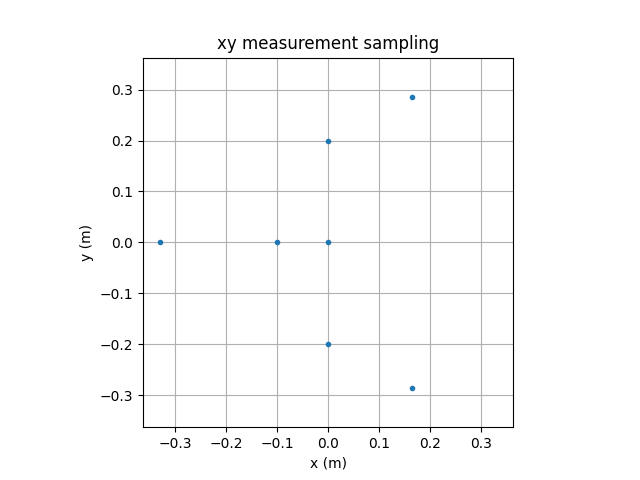

In [138]:
random.seed(15)

xy_list = np.empty((0, 2))
for i in range(len(r_fit)):
    rad = r_fit[i]
    for j in φ_fit[i]:
        xy_list = np.append(xy_list, np.array([[rad*np.cos(j), rad*np.sin(j)]]), axis = 0)

plt.close()
plt.figure()
plt.plot(xy_list.transpose()[0], xy_list.transpose()[1], ".")
plt.xlabel("x (m)")
plt.ylabel("y (m)")
view_bounds = 1.1*max(r_fit)
plt.xlim((-view_bounds, view_bounds))
plt.ylim((-view_bounds, view_bounds))

ax = plt.gca()
ax.set_aspect('equal', adjustable='box')
plt.title("xy measurement sampling")
ax.grid()
# plt.savefig("measurement_array.png")


plt.show()

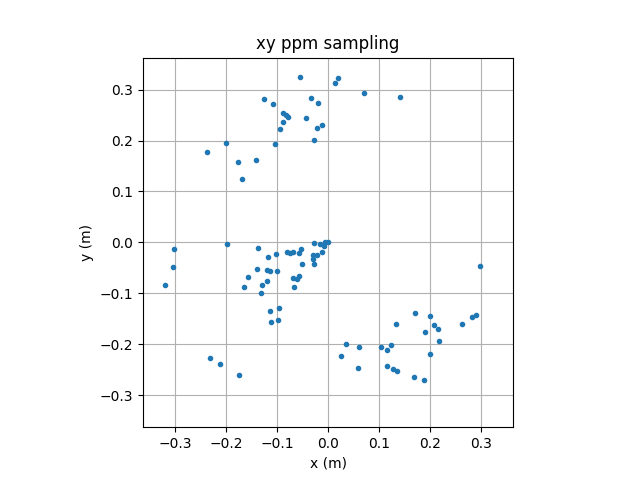

In [139]:
xy_ppm = np.empty((0, 2))
for i in range(len(r_ppm)):
    rad = r_ppm[i]
    for j in φ_ppm[i]:
        rand_num = random.random() # Trying to determine whether it is better to leave organized or not
        xy_ppm = np.append(xy_ppm, np.array([[rad*np.cos(j+rand_num), rad*np.sin(j+rand_num)]]), axis = 0)

plt.close()
plt.figure()
plt.plot(xy_ppm.transpose()[0], xy_ppm.transpose()[1], ".")
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.title("xy ppm sampling")
view_bounds = 1.1*max(r_fit)
plt.xlim((-view_bounds, view_bounds))
plt.ylim((-view_bounds, view_bounds))

ax = plt.gca()
ax.set_aspect('equal', adjustable='box')
ax.grid()
plt.show()

In [140]:
def loop_B_numeric(r: NDArray, z0: float, R: float, offset: float = 0, I: float = 1.0, nseg: int = 720) -> tuple:
    """ Computes the effect of a circular current in the x-y plane centered on (0, offset, z0) at the point r

    Parameters
    ----------
    r: NDArray
        An array of the form [x, y, z] to compute the field at
    z0: float
        The z-coordinate of the current loop
    R: float
        The radius of the current loop
    offset: float
        A possible y-shift to the center of the current loop
    I: float
        The current (in A) of the loop (default = 1)
    nseg: int
        The number of line segments to break the loop into (default = 720)

    Returns
    -------
        tuple: 
            (Bx, By, Bz), the x, y, and z components of the magnetic field at r
    """
    grid = np.array(r)
    coil = loop_discretization(R, z0, n = nseg, offset = offset)
    bfield_params = bfield_inputs(coil, grid, currents = np.array([I]))
    field = bfield(bfield_params["coil"], bfield_params["grid"], bfield_params["current"])
    return field[0, 0], field[0, 1], field[0, 2]

def build_M_B(xy_list, z_list, z_coils, R_coils, offset = offset, nseg=720, I: NDArray | None = None):
    """ Creates a matrix
    
    """
    npts = len(xy_list) * len(z_list)  
    n_coils = len(z_coils)

    Mx = np.zeros((npts, n_coils), dtype=float)
    My = np.copy(Mx)
    Mz = np.copy(Mx)

    if I is None:
        I = 1

    row = 0
    for r in xy_list:
      
        for z in z_list:
            for j, (zc, Rc) in enumerate(zip(z_coils, R_coils)):
                Mx[row, j], My[row, j], Mz[row, j] = loop_B_numeric(np.array([r[0], r[1], z]), zc, Rc, offset=offset[j], I = I[j], nseg=nseg)
            row += 1
    return Mx, My, Mz

In [141]:
coil_list = []
for j, (zc, Rc) in enumerate(zip(z_coils, R_coils)):
    coil_list.append(loop_discretization(Rc, zc, n = n_seg, offset = offset[j]))
grid = np.zeros((len(z_fit) * n_rφ, 3))
for i in range(len(z_fit)):
    for j in range(n_rφ):
        grid[i*n_rφ + j] = np.array([xy_list[j, 0], xy_list[j, 1], z_fit[i]])
bfield_params = bfield_inputs(coil_list, grid, I_sol)
field_dev_M = build_M_bfield(bfield_params["coil"], bfield_params["grid"], bfield_params["current"])


M_dev_fit_z = np.copy(field_dev_M["Bz"])
b_dev_fit = np.full(M_fit.shape[0], B0, dtype=float)

# Get Radial - no offset

In [142]:
coil_list = []
for j, (zc, Rc) in enumerate(zip(z_coils, R_coils)):
    coil_list.append(loop_discretization(Rc, zc, n = n_seg))
grid = np.zeros((len(z_fit) * n_rφ, 3))
for i in range(len(z_fit)):
    for j in range(n_rφ):
        grid[i*n_rφ + j] = np.array([xy_list[j, 0], xy_list[j, 1], z_fit[i]])
bfield_params = bfield_inputs(coil_list, grid, I_sol)
field_base_M = build_M_bfield(bfield_params["coil"], bfield_params["grid"], bfield_params["current"])

M_base_fit_z = np.copy(field_base_M["Bz"])
b_base_fit = np.full(M_fit.shape[0], B0, dtype=float)

# Subtracting fields

In [143]:
print(φ_fit)

[array([3.14159265]), array([3.14159265]), array([1.57079633, 4.71238898]), array([1.04719755, 3.14159265, 5.23598776])]


In [144]:
r_list = np.linalg.norm(xy_list, axis = 1)
len(r_list)/4 * 12000
print(xy_list)

[[-0.00000000e+00  0.00000000e+00]
 [-1.00000000e-01  1.22464680e-17]
 [ 1.22464680e-17  2.00000000e-01]
 [-3.67394040e-17 -2.00000000e-01]
 [ 1.65000000e-01  2.85788383e-01]
 [-3.30000000e-01  4.04133444e-17]
 [ 1.65000000e-01 -2.85788383e-01]]


In [145]:
print(grid)
np.linalg.norm(grid, axis = 1)

[[-0.00000000e+00  0.00000000e+00 -1.74999976e+00]
 [-1.00000000e-01  1.22464680e-17 -1.74999976e+00]
 [ 1.22464680e-17  2.00000000e-01 -1.74999976e+00]
 ...
 [ 1.65000000e-01  2.85788383e-01  1.74999976e+00]
 [-3.30000000e-01  4.04133444e-17  1.74999976e+00]
 [ 1.65000000e-01 -2.85788383e-01  1.74999976e+00]]


array([1.74999976, 1.75285457, 1.76139126, ..., 1.78084226, 1.78084226,
       1.78084226], shape=(21000,))

In [146]:
max_z = max(np.abs(field_base_M["Bz"] @ np.ones_like(I) - field_dev_M["Bz"] @ np.ones_like(I)))
max_x = max(np.abs(field_base_M["Bx"] @ np.ones_like(I) - field_dev_M["Bx"] @ np.ones_like(I)))
max_y = max(np.abs(field_base_M["By"] @ np.ones_like(I) - field_dev_M["By"] @ np.ones_like(I)))

δx = max_x / B0
δy = max_y / B0
δz = max_z / B0

print(f"Variation δx = |Bx_base - Bx_sag| / B0 = {δx}")
print(f"Variation δy = |By_base - By_sag| / B0 = {δy}")
print(f"Variation δz = |Bz_base - Bz_sag| / B0 = {δz}")

# despite machine precision, should be accurate to 

Variation δx = |Bx_base - Bx_sag| / B0 = 1.8964963017719303e-07
Variation δy = |By_base - By_sag| / B0 = 7.7897300811044e-05
Variation δz = |Bz_base - Bz_sag| / B0 = 1.3280369890247834e-05


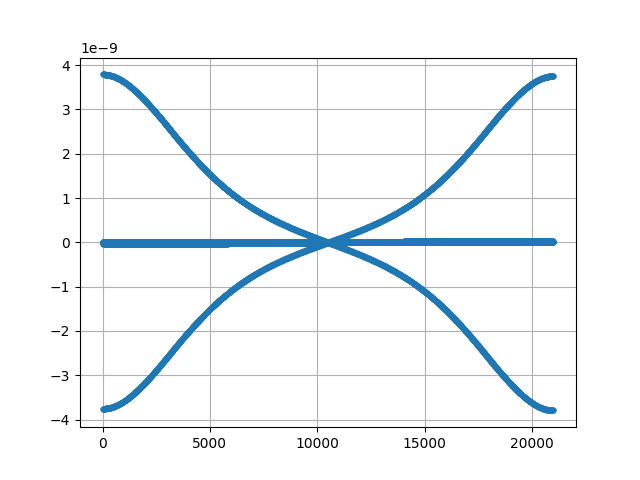

[ 5.38838686e-19 -1.19321746e-11 -2.61633919e-19 ... -3.79299260e-09
  3.90332858e-11  3.75472763e-09]
4
20997


np.float64(1.1925959199544532e-19)

In [147]:
y_diff = field_base_M["Bx"] @ np.ones_like(I) - field_dev_M["Bx"] @ np.ones_like(I)

plt.close()
plt.figure()
plt.plot(y_diff, ".")
plt.grid()
plt.show()
print(y_diff)
print(np.argmax(y_diff))
print(np.argmin(y_diff))
y_diff[len(y_diff) // 2]

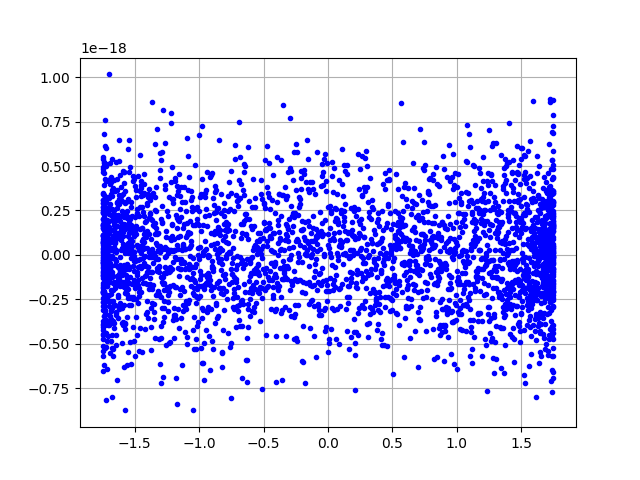

[array([3.14159265]), array([3.14159265]), array([1.57079633, 4.71238898]), array([1.04719755, 3.14159265, 5.23598776])]


In [148]:
i = 0
φ_len = sum(len(r) for r in φ_fit)
plt.close()
plt.figure()
plt.grid()
for n in range(len(y_diff)):
    if n % φ_len == 0:
        plt.plot(z_fit[i], y_diff[n], "b.")
        i += 1
# i = 0
# for n in range(len(y_diff)):
#     if n % φ_len == 4:
#         plt.plot(z_fit[i], y_diff[n], "r.")
#         i += 1
plt.show()
print(φ_fit)

In [149]:
plt.close()
plt.plot(field_base_M["Bz"] @ np.ones_like(I) - B0)

# Visualizing Results

In [227]:
def set_axes_equal(ax):
    x_limits = ax.get_xlim3d()
    y_limits = ax.get_ylim3d()
    z_limits = ax.get_zlim3d()

    x_range = abs(x_limits[1] - x_limits[0])
    y_range = abs(y_limits[1] - y_limits[0])
    z_range = abs(z_limits[1] - z_limits[0])

    x_middle = np.mean(x_limits)
    y_middle = np.mean(y_limits)
    z_middle = np.mean(z_limits)

    radius = 0.5 * max(x_range, y_range, z_range)

    ax.set_xlim3d([x_middle - radius, x_middle + radius])
    ax.set_ylim3d([y_middle - radius, y_middle + radius])
    ax.set_zlim3d([z_middle - radius, z_middle + radius])

    ax.set_box_aspect([1, 1, 1])

In [151]:
plt.close()

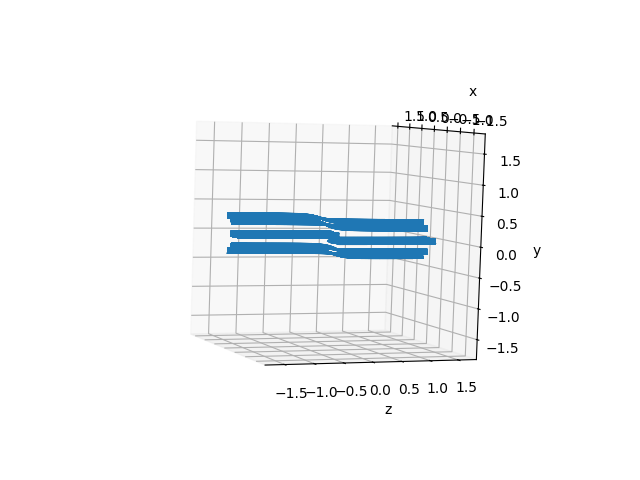

In [228]:
plt.close()
ax = plt.figure().add_subplot(projection='3d')
x_pts = grid[:, 0]
y_pts = grid[:, 1]
z_pts = grid[:, 2]

ΔBx = field_base_M["Bx"] @ np.ones_like(I) - field_dev_M["Bx"] @ np.ones_like(I)
ΔBy = field_base_M["By"] @ np.ones_like(I) - field_dev_M["By"] @ np.ones_like(I)
ΔBz = field_base_M["Bz"] @ np.ones_like(I) - field_dev_M["Bz"] @ np.ones_like(I)



ax.quiver(x_pts, y_pts, z_pts, ΔBx, ΔBy, ΔBz, normalize=True, length = 0.1)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.view_init(elev=-22.5, azim=175, roll=-90)
set_axes_equal(ax)
plt.show()

Because the variation in the x-axis is so small, I'll plot a projection of the vector field into the y-z plane

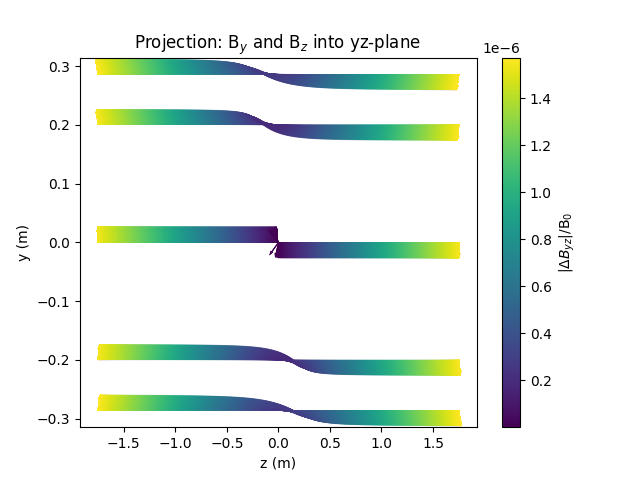

In [229]:
plt.close()
plt.figure()

plt.xlabel("z (m)")
plt.ylabel("y (m)")



# Compute magnitude
mag = np.sqrt(ΔBz**2 + ΔBy**2)

# Normalize
u_norm = ΔBz / mag
v_norm = ΔBy / mag



plt.quiver(z_pts, y_pts, u_norm, v_norm, mag, cmap='viridis',pivot = 'tail', scale = 25)
plt.colorbar(label=r'$|\Delta B_{{yz}}|$/B$_0$')
plt.title(fr"Projection: B$_y$ and B$_z$ into yz-plane ")
plt.savefig("yz_proj.png")
plt.show()

## Animation xy Plane 

In [154]:
# import numpy as np
# import matplotlib.pyplot as plt
# import matplotlib.animation as animation
# import matplotlib as mpl
# from IPython.display import HTML


# # --- inputs ---
# # xy_list: shape (n_points, 2)
# # z_fit:   shape (n_z,)
# # ΔBx, ΔBy: flat arrays of length n_z * n_points
# # r_fit: used only for view bounds

# xy = np.asarray(xy_list)[:, :2]
# x = xy[:, 0]
# y = xy[:, 1]

# n_points = len(xy_list)
# n_z = len(z_fit)

# # reshape flat arrays into [z_index, point_index]
# dBx_frames = np.asarray(ΔBx).reshape(n_z, n_points)
# dBy_frames = np.asarray(ΔBy).reshape(n_z, n_points)

# # magnitude for color
# mag_frames = np.hypot(dBx_frames, dBy_frames)

# # direction from angle, so orientation is preserved explicitly
# theta_frames = np.arctan2(dBy_frames, dBx_frames)

# # fixed arrow length for display only
# arrow_len = 0.08
# Ux_frames = np.cos(theta_frames) * arrow_len
# Uy_frames = np.sin(theta_frames) * arrow_len

# # draw only every 50th frame
# frame_step = 7
# frame_indices = np.arange(0, n_z, frame_step)

# # log color scale, avoiding zeros
# positive_mag = mag_frames[mag_frames > 0]
# if positive_mag.size == 0:
#     raise ValueError("All magnitudes are zero, so LogNorm cannot be used.")

# color_min = positive_mag.min()
# color_max = positive_mag.max()
# color_frames = np.clip(mag_frames, color_min, None)

# norm = mpl.colors.LogNorm(vmin=color_min, vmax=color_max)
# cmap = plt.cm.viridis

# plt.close()
# fig, ax = plt.subplots(figsize=(6, 6))

# view_bounds = 1.1 * max(r_fit)
# ax.set_xlim(-view_bounds, view_bounds)
# ax.set_ylim(-view_bounds, view_bounds)
# ax.set_aspect('equal', adjustable='box')
# ax.set_xlabel("x (m)")
# ax.set_ylabel("y (m)")

# first_frame = frame_indices[0]

# q = ax.quiver(
#     x, y,
#     Ux_frames[first_frame], Uy_frames[first_frame],
#     color_frames[first_frame],
#     angles='xy',
#     scale_units='xy',
#     scale=1,
#     cmap=cmap,
#     norm=norm,
#     pivot = 'mid'
# )

# cbar = fig.colorbar(q, ax=ax)
# cbar.set_label(r"$|\Delta B_{xy}|/B_0$")

# title = ax.set_title(f"z = {z_fit[first_frame]:.3f} m")

# def update(i):
#     frame = frame_indices[i]
#     q.set_UVC(
#         Ux_frames[frame],
#         Uy_frames[frame],
#         color_frames[frame]
#     )
#     title.set_text(f"z = {z_fit[frame]:.3f} m")
#     return q, title

# ani = animation.FuncAnimation(
#     fig,
#     update,
#     frames=len(frame_indices),
#     interval=200,
#     blit=False
# )

# HTML(ani.to_jshtml())

In [155]:
# ani.save(
#     "deltaB_animation.gif",
#     writer="pillow",
#     fps=30,
#     dpi=200
# )

# Cos(θ) coil

In [156]:
def make_cosθ_coil(R: float, angle: float, zmin: float, zmax: float, is_radians: bool = False) -> NDArray:
    """ Creates an array of points for a cosθ coil at a particular angle 
    
    Parameters
    ----------
    R: float
        Radius of the solenoid
    angle: float
        Angle relative to vertical of where along the solenoid the loop will go, default is in degrees. 
    zmin: float
        Minimum z-position of the coil
    zmax: float
        Maximum z-position of the coil
    is_radians: bool
        Angle is passed in radians if true, or degrees if false.

    Returns
    -------
    NDArray:
        A (5, 3) array that describes segments in the loop for use in the magnetic field generation code


    """

    coil = np.zeros((5, 3))
    if is_radians:
        angle_conv = 1
    else:
        angle_conv = np.pi/180

    y = R*np.cos(angle*angle_conv)
    pos_x = R*np.sin(angle*angle_conv)
    neg_x = -pos_x



    for i in range(len(coil)):
        coil[i, 1] = y
        if i == 0:
            coil[i, 0] = pos_x
            coil[i, -1] = zmin
        elif i == 1:
            coil[i, 0] = pos_x
            coil[i, -1] = zmax
        elif i == 2:
            coil[i, 0] = neg_x
            coil[i, -1] = zmax
        elif i == 3:
            coil[i, 0] = neg_x
            coil[i, -1] = zmin
        elif i == 4:
            coil[i, 0] = pos_x
            coil[i, -1] = zmin
        else:
            raise ValueError("Wrong dimensions for cos(θ) coil")


    return coil


In [157]:
cos_coil_list = []
num_cos_coils = 10
angles, Δangle = np.linspace(0, 180, num_cos_coils + 2, retstep=True)
for angle in angles[1:-1]:
    cos_coil_list.append(make_cosθ_coil(Rc, angle, z_min, z_max))
# print(cos_coil_list)

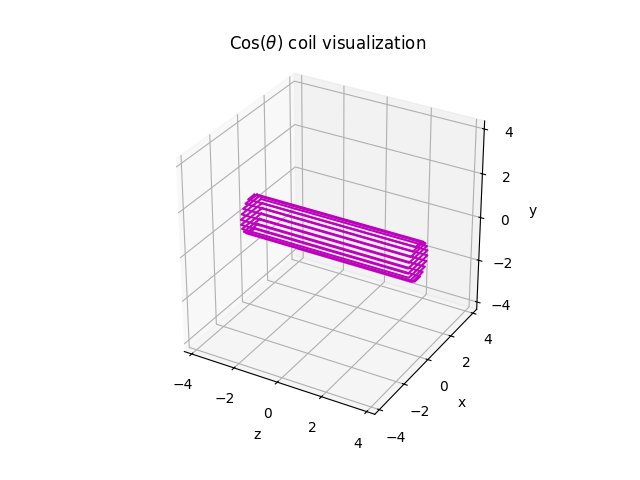

In [158]:
plt.close()
fig, ax = plt.subplots(subplot_kw={'projection': '3d'})
for coil in cos_coil_list:
    ax.plot(coil[:, 2], coil[:, 0], coil[:, 1], "m-")
ax.set_xlabel("z")
ax.set_ylabel("x")
ax.set_zlabel("y")
ax.set_title(fr"Cos($\theta$) coil visualization")
set_axes_equal(ax)
plt.savefig("cos_visualization.png")
plt.show()

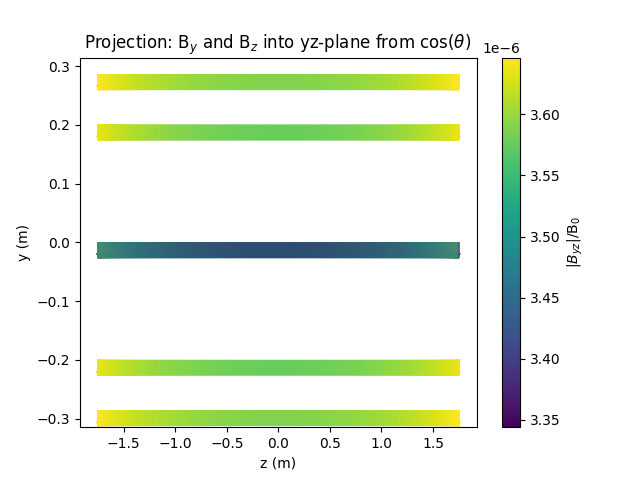

In [159]:
cos_currents = np.array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1])
cos_inputs = bfield_inputs(cos_coil_list, grid, currents = cos_currents)
cos_field = build_M_bfield(cos_inputs["coil"], cos_inputs["grid"], cos_inputs["current"])

cos_Bx = cos_field["Bx"] @ np.ones_like(cos_inputs["current"])
cos_By = cos_field["By"] @ np.ones_like(cos_inputs["current"])
cos_Bz = cos_field["Bz"] @ np.ones_like(cos_inputs["current"])

plt.close()
plt.figure()

plt.xlabel("z (m)")
plt.ylabel("y (m)")


# Compute magnitude
mag = np.sqrt(cos_Bz**2 + cos_By**2)

# Normalize
u_norm = cos_Bz / mag
v_norm = cos_By / mag



plt.quiver(z_pts, y_pts, u_norm, v_norm, mag, cmap='viridis',pivot = 'tail', scale = 25)
plt.colorbar(label=r'$|B_{{yz}}|$/B$_0$')
plt.title(fr"Projection: B$_y$ and B$_z$ into yz-plane from cos($\theta$) ")
plt.savefig("cos_yz_proj.png")
plt.show()

# Cylinder Sampling

Radius of correcting coils: 0.5614018691588786


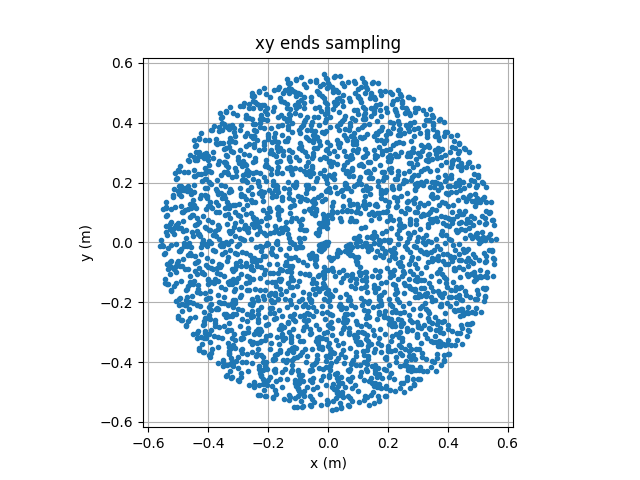

In [310]:
n_cyl_z = 1000
n_cyl_φ = 100
n_end_r = 200
n_end_φscale = 50



radial_offset = -1.75*dz_main*2
z_off = 1e-4# radial_offset
cyl_r = R_main + radial_offset
print(f"Radius of correcting coils: {cyl_r}")



cyl_z_arr, dz_cyl = np.linspace(z_min - z_off, z_max + z_off, n_cyl_z, retstep=True)
cyl_φ_arr, dφ_cyl = np.linspace(0, 2*np.pi, n_cyl_φ, retstep=True, endpoint=False)
cyl_x_arr = (cyl_r)*np.cos(cyl_φ_arr)
cyl_y_arr = (cyl_r)*np.sin(cyl_φ_arr)
end_r_arr, dr_end = np.linspace(0, cyl_r, n_end_r, retstep=True)

end_φ_arr = φ_from_r(end_r_arr, n_end_φscale)["φ_list"]
random.seed(22)


end_xy_list = np.empty((0, 3))
for i in range(len(end_r_arr)):
    rand_off = random.random()
    rad = end_r_arr[i]
    for j in end_φ_arr[i]:
        end_xy_list = np.append(end_xy_list, np.array([[rad*np.cos(j + rand_off), rad*np.sin(j + rand_off), z_min - z_off]]), axis = 0)

plt.close()
plt.figure()
plt.plot(end_xy_list.transpose()[0], end_xy_list.transpose()[1], ".")
plt.xlabel("x (m)")
plt.ylabel("y (m)")
end_view_bounds = 1.1*max(end_r_arr)
plt.xlim((-end_view_bounds, end_view_bounds))
plt.ylim((-end_view_bounds, end_view_bounds))

ax = plt.gca()
ax.set_aspect('equal', adjustable='box')
plt.title("xy ends sampling")
ax.grid()
# plt.savefig("measurement_array.png")


plt.show()

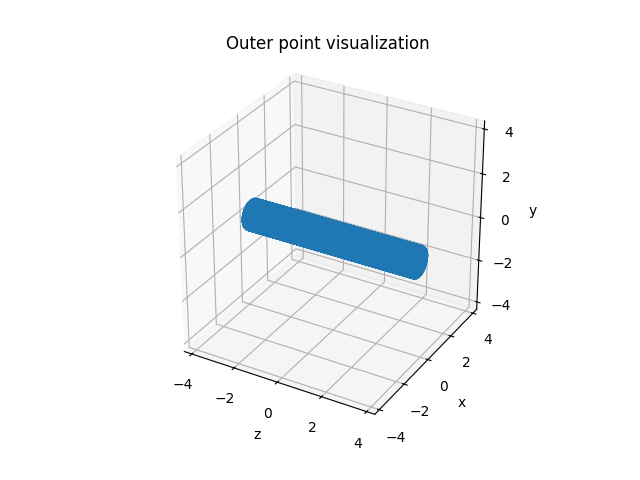

In [311]:


cyl_grid = np.zeros((n_cyl_z * n_cyl_φ, 3))
for i in range(n_cyl_z):
    for j in range(n_cyl_φ):
        cyl_grid[i*n_cyl_φ + j] = np.array([cyl_x_arr[j], cyl_y_arr[j], cyl_z_arr[i]])


out_grid = np.concatenate((cyl_grid, end_xy_list, end_xy_list * np.array([1, 1, -1])), axis = 0)

plt.close()
fig, ax = plt.subplots(subplot_kw={'projection': '3d'})

ax.plot(out_grid[:, 2], out_grid[:, 0], out_grid[:, 1], ".")
ax.set_xlabel("z")
ax.set_ylabel("x")
ax.set_zlabel("y")
ax.set_title(fr"Outer point visualization")
set_axes_equal(ax)
# plt.savefig("cos_visualization.png")
plt.show()


In [312]:
coil_list = []
for j, (zc, Rc) in enumerate(zip(z_coils, R_coils)):
    coil_list.append(loop_discretization(Rc, zc, n = n_seg, offset = offset[j]))

bfield_params = bfield_inputs(coil_list, cyl_grid, I_sol)
cyl_field_dev_M = build_M_bfield(bfield_params["coil"], bfield_params["grid"], bfield_params["current"])


cyl_M_dev_fit_z = np.copy(field_dev_M["Bz"])
cyl_b_dev_fit = np.full(M_fit.shape[0], B0, dtype=float)


coil_list = []
for j, (zc, Rc) in enumerate(zip(z_coils, R_coils)):
    coil_list.append(loop_discretization(Rc, zc, n = n_seg))

bfield_params = bfield_inputs(coil_list, cyl_grid, I_sol)
cyl_field_base_M = build_M_bfield(bfield_params["coil"], bfield_params["grid"], bfield_params["current"])

cyl_M_base_fit_z = np.copy(field_base_M["Bz"])
cyl_b_base_fit = np.full(M_fit.shape[0], B0, dtype=float)

In [313]:
print(np.shape(end_xy_list))
print(np.shape(cyl_grid))

(2715, 3)
(100000, 3)


In [314]:
coil_list = []
for j, (zc, Rc) in enumerate(zip(z_coils, R_coils)):
    coil_list.append(loop_discretization(Rc, zc, n = n_seg, offset = offset[j]))
print("Made offset coils!\n")

end_bfield_params = bfield_inputs(coil_list, end_xy_list, I_sol)
print("Created inputs to find B-field...")

end_field_dev_M = build_M_bfield(end_bfield_params["coil"], end_bfield_params["grid"], end_bfield_params["current"])
print("Computed field from offset coils\n\n")


# end_M_dev_fit_z = np.copy(field_dev_M["Bz"])
# end_b_dev_fit = np.full(M_fit.shape[0], B0, dtype=float)


coil_list = []
for j, (zc, Rc) in enumerate(zip(z_coils, R_coils)):
    coil_list.append(loop_discretization(Rc, zc, n = n_seg))
print("Made base coils!\n")

end_bfield_params = bfield_inputs(coil_list, end_xy_list, I_sol)
print("Created inputs to find B-field...")
end_field_base_M = build_M_bfield(end_bfield_params["coil"], end_bfield_params["grid"], end_bfield_params["current"])

# end_M_base_fit_z = np.copy(field_base_M["Bz"])
# end_b_base_fit = np.full(M_fit.shape[0], B0, dtype=float)
print("Computed field from base coils")

Made offset coils!

Created inputs to find B-field...
Computed field from offset coils


Made base coils!

Created inputs to find B-field...
Computed field from base coils


In [315]:
cyl_ΔBx = cyl_field_base_M["Bx"] @ np.ones_like(I) - cyl_field_dev_M["Bx"] @ np.ones_like(I)
cyl_ΔBy = cyl_field_base_M["By"] @ np.ones_like(I) - cyl_field_dev_M["By"] @ np.ones_like(I)
cyl_ΔBz = cyl_field_base_M["Bz"] @ np.ones_like(I) - cyl_field_dev_M["Bz"] @ np.ones_like(I)


# plt.close()
# ax = plt.figure().add_subplot(projection='3d')
cyl_x_pts = cyl_grid[:, 0]
cyl_y_pts = cyl_grid[:, 1]
cyl_z_pts = cyl_grid[:, 2]


end_ΔBx = end_field_base_M["Bx"] @ np.ones_like(I) - end_field_dev_M["Bx"] @ np.ones_like(I)
end_ΔBy = end_field_base_M["By"] @ np.ones_like(I) - end_field_dev_M["By"] @ np.ones_like(I)
end_ΔBz = end_field_base_M["Bz"] @ np.ones_like(I) - end_field_dev_M["Bz"] @ np.ones_like(I)


# plt.close()
# ax = plt.figure().add_subplot(projection='3d')
end_x_pts = end_xy_list[:, 0]
end_y_pts = end_xy_list[:, 1]
end_z_pts = end_xy_list[:, 2]


# ax.quiver(cyl_x_pts, cyl_y_pts, cyl_z_pts, cyl_ΔBx, cyl_ΔBy, cyl_ΔBz, normalize=True, length = 0.1)
# ax.set_xlabel("x")
# ax.set_ylabel("y")
# ax.set_zlabel("z")
# ax.view_init(elev=-22.5, azim=175, roll=-90)
# set_axes_equal(ax)
# plt.show()


In [316]:
end_field_base_M["Bz"] @ np.ones_like(I)

array([0.01015152, 0.01015151, 0.01015149, ..., 0.00981367, 0.00981367,
       0.00981367], shape=(2715,))

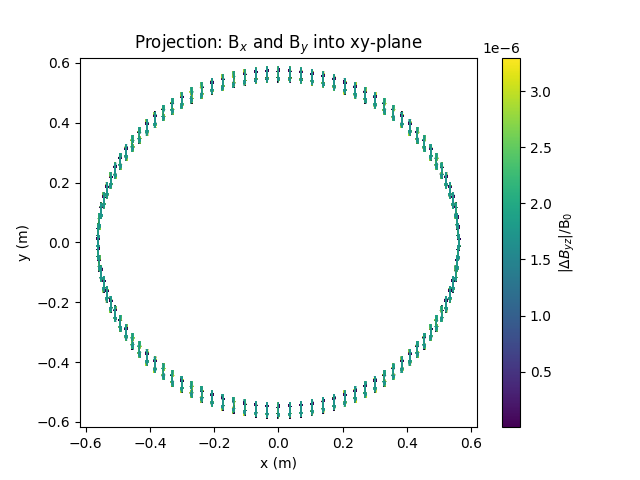

In [317]:
plt.close()
plt.figure()

plt.xlabel("x (m)")
plt.ylabel("y (m)")



# Compute magnitude
mag = np.sqrt(cyl_ΔBx**2 + cyl_ΔBy**2)

# Normalize
u_norm = cyl_ΔBx / mag
v_norm = cyl_ΔBy / mag



plt.quiver(cyl_x_pts, cyl_y_pts, u_norm, v_norm, mag, cmap='viridis',pivot = 'middle', scale = 25)
plt.colorbar(label=r'$|\Delta B_{{yz}}|$/B$_0$')
plt.title(fr"Projection: B$_x$ and B$_y$ into xy-plane ")
plt.savefig("xy_proj.png")
plt.show()

Convert data into that needed for txt file for Comsol

In [318]:
cyl_points = np.zeros((len(cyl_grid), 2))
for i in range(len(cyl_points)):
    cyl_points[i, 0] = np.angle(cyl_grid[i, 0] + 1j * cyl_grid[i, 1]) % (2*np.pi)
    if cyl_points[i, 0] > np.pi:
        cyl_points[i, 0] -= 2*np.pi
    cyl_points[i, 1] = cyl_z_pts[i]
# print(cyl_points)

np.savetxt("./saved_data/cyl_grid.csv", cyl_points, delimiter=",", header = "phi, z")

cyl_norm_field = np.zeros(len(cyl_grid))
for i in range(len(cyl_norm_field)):
    cyl_angle = cyl_points[i, 0]
    cyl_norm_field[i] = (cyl_ΔBx[i]*np.cos(cyl_angle) + cyl_ΔBy[i]*np.sin(cyl_angle))*-1
np.savetxt("./saved_data/cyl_normal_field.csv", cyl_norm_field, delimiter=",", header = "Inward normal components of field")



end_points = np.zeros((len(end_xy_list), 2))
# back_end_points = np.copy(front_end_points)
for i in range(len(end_xy_list)):
    end_points[i, 1] = np.angle(end_xy_list[i, 0] + 1j * end_xy_list[i, 1]) % (2*np.pi)
    if end_points[i, 1] > np.pi:
        end_points[i, 1] -= 2*np.pi
    end_points[i, 0] = np.sqrt(end_xy_list[i, 0]**2 + end_xy_list[i, 1]**2)
    # else:
    #     back_end_points[i, 1] = np.angle(end_xy_list[i, 0] + 1j * end_xy_list[i, 1]) % (2*np.pi)
    #     back_end_points[i, 0] = np.sqrt(end_xy_list[i, 0]**2 + end_xy_list[i, 1]**2)
# print(end_points)

np.savetxt("./saved_data/end_grid.csv", end_points, delimiter=",", header = f"rho, phi (z = {z_min - z_off})")

end_norm_field = np.copy(end_ΔBz)
np.savetxt("./saved_data/end_normal_field.csv", end_norm_field, delimiter=",", header = f"Inward normal components of field (z = {z_min - z_off})")

I need to somehow combine these into single text/csv files

In [319]:
# cyl_r_arr = np.ones(len(cyl_points))*(R_main + radial_offset)
# cyl_comsol = np.column_stack((cyl_r_arr, cyl_points, cyl_norm_field))
# np.savetxt("./saved_data/cyl_comsol.csv", cyl_comsol, delimiter=",", header = f"Cylinder inward normal field sampling, r = {R_main + radial_offset} \nr phi z Bn", comments = "% ")

cyl_comsol = np.column_stack((cyl_points, cyl_norm_field))
np.savetxt("./saved_data/cyl_comsol.csv", cyl_comsol, delimiter=",", header = f"Cylinder inward normal field sampling, r = {R_main + radial_offset} \nphi z Bn", comments = "% ")

# end_z_arr = np.ones(len(end_points))*(z_min - z_off)
# end_comsol = np.column_stack((end_points, end_z_arr, end_norm_field))
# np.savetxt("./saved_data/end_comsol.csv", end_comsol, delimiter=",", header = f"End inward normal field sampling, z = {z_min  - z_off} \nr phi z Bn", comments = "% ")


end_comsol = np.column_stack((end_points, end_norm_field))
np.savetxt("./saved_data/end_comsol.csv", end_comsol, delimiter=",", header = f"End inward normal field sampling, z = {z_min  - z_off} \nr phi Bn", comments = "% ")

In [282]:
xyz_cyl_Bn = np.column_stack((cyl_grid, cyl_norm_field))
np.savetxt("./saved_data/xyz_cyl_comsol.csv", xyz_cyl_Bn, delimiter=",", header = f"Cylinder inward normal field sampling, r = {R_main + radial_offset} \nx y z Bn", comments = "% ")

xyz_end_Bn = np.column_stack((end_xy_list, end_norm_field))
np.savetxt("./saved_data/xyz_end_comsol.csv", xyz_end_Bn, delimiter=",", header = f"Cylinder inward normal field sampling, z = {z_min - z_off} \nx y z Bn", comments = "% ")

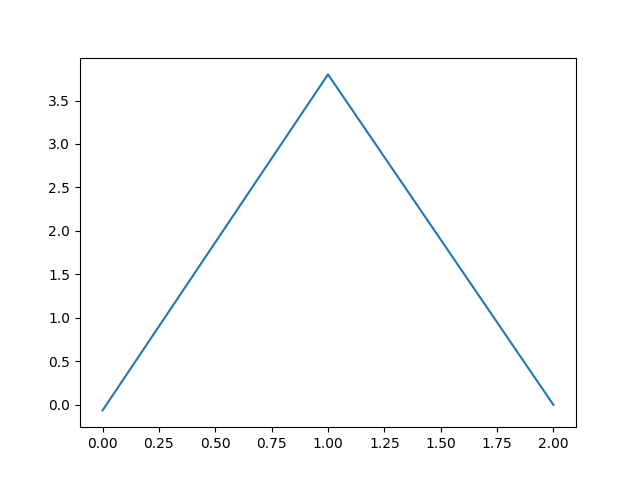

In [283]:
plt.close()
plt.figure()
plt.plot(cyl_comsol[-1, :])

In [284]:
cyl_comsol

array([[ 0.00000000e+00, -3.80010000e+00,  2.40848962e-10],
       [ 6.28318531e-02, -3.80010000e+00,  7.37731284e-08],
       [ 1.25663706e-01, -3.80010000e+00,  1.47014360e-07],
       ...,
       [-1.88495559e-01,  3.80010000e+00,  2.19164916e-07],
       [-1.25663706e-01,  3.80010000e+00,  1.46511653e-07],
       [-6.28318531e-02,  3.80010000e+00,  7.32800594e-08]],
      shape=(100000, 3))

# Save Measured Positions and Fields

In [285]:

# save_data = {
#     "x_pos": x_pts, 
#     "y_pos": y_pts,
#     "z_pos": z_pts,
#     "Bx_base": field_base_M["Bx"] @ np.ones_like(I),
#     "Bx_dev": field_dev_M["Bx"] @ np.ones_like(I),
#     "By_base": field_base_M["By"] @ np.ones_like(I),
#     "By_dev": field_dev_M["By"] @ np.ones_like(I),
#     "Bz_base": field_base_M["Bz"] @ np.ones_like(I),
#     "Bz_dev": field_dev_M["Bz"] @ np.ones_like(I)
#     }



# np.savetxt("./saved_data/x_pos.csv", save_data["x_pos"], delimiter=",")
# np.savetxt("./saved_data/y_pos.csv", save_data["y_pos"], delimiter=",")
# np.savetxt("./saved_data/z_pos.csv", save_data["z_pos"], delimiter=",")
# np.savetxt("./saved_data/Bx_base.csv", save_data["Bx_base"], delimiter=",")
# np.savetxt("./saved_data/By_base.csv", save_data["By_base"], delimiter=",")
# np.savetxt("./saved_data/Bz_base.csv", save_data["Bz_base"], delimiter=",")
# np.savetxt("./saved_data/Bx_dev.csv", save_data["Bx_dev"], delimiter=",")
# np.savetxt("./saved_data/By_dev.csv", save_data["By_dev"], delimiter=",")
# np.savetxt("./saved_data/Bz_dev.csv", save_data["Bz_dev"], delimiter=",")

In [286]:
cyl_comsol[628][0]

np.float64(1.7592918860102844)

2.0106192982974678


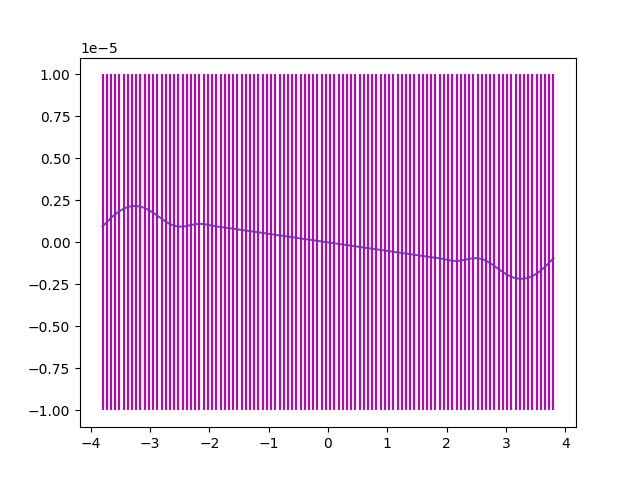

In [287]:
adjust = 37
print(cyl_comsol[595 + adjust,0])
cyl_dat = cyl_comsol[cyl_comsol[:,0]==cyl_comsol[598 + adjust,0],2]
cyl_z = cyl_comsol[cyl_comsol[:,0]==cyl_comsol[598 + adjust,0],-2]
plt.close()
plt.figure()
plt.plot(cyl_z, cyl_dat)
plt.vlines(z_coils, -1e-5, 1e-5, "m")
plt.show()

In [288]:
dz_main

np.float64(0.07102803738317756)

# Helmholtz Testing

In [289]:
def loop_discretization_h(R: float, z: float, n: int = 720, offset: float = 0) -> NDArray:
    """ Use Biot-Savart straight line discretization to convert a circular loop centered at (0, offset, z) of radius R into n line segments. 
    
    Parameters
    -----------
    R: float 
        The radius of the loop
    z: float
        The z-coordinate of the loop, where the loop is in the x-y plane
    n: int 
        The number of line segments to break the loop into (default: 720)
    offset: float
        A possible y-shift to the center of the loop

    
    Returns
    --------
        NDArray: An (n+1, 3) array of points, where each pair corresponds to a line segment of the loop
    """
    

    
    # Can adjust as needed to match Mubi's if we determine the arc length method is still applicable. I want to first consider all magnetic effects.
    
    θ, dθ = np.linspace(0, 2*np.pi, n + 1, retstep=True)
    x = R*np.cos(θ)
    y = np.ones_like(x)*offset
    z = R*np.sin(θ)
    coil_points = np.array([x, y, z]).transpose()

    return coil_points

In [290]:
R_helmholtz = 5000000
n_seg_h = 10000
loop1_h = loop_discretization_h(R_helmholtz, 0, n = n_seg_h, offset = R_helmholtz/2) 
loop2_h = loop_discretization_h(R_helmholtz, 0, n = n_seg_h, offset = -R_helmholtz/2) 
coil_list_h = np.array([loop1_h, loop2_h])
currents_h = np.array([-100000000, -100000000])

bfield_h_params = bfield_inputs(coil_list_h, cyl_grid, currents_h)
cyl_h_base_M = build_M_bfield(bfield_h_params["coil"], bfield_h_params["grid"], bfield_h_params["current"])

In [291]:
# np.max(cyl_h_base_M['By'])
print(np.max(abs(cyl_h_base_M["Bx"]@np.array([1, 1]))))
print(np.max(abs(cyl_h_base_M["By"]@np.array([1, 1]))))
print(np.max(abs(cyl_h_base_M["Bz"]@np.array([1, 1]))))

1.4000703951707693e-20
1.7983525945743717e-05
2.5243598444428353e-20


In [292]:
np.savetxt("./saved_data/uniform_y.csv", cyl_h_base_M["By"]@np.array([1, 1]), delimiter=",")

In [293]:
cyl_points_h = np.zeros((len(cyl_grid), 2))
for i in range(len(cyl_points_h)):
    cyl_points_h[i, 0] = np.angle(cyl_grid[i, 0] + 1j * cyl_grid[i, 1]) 
    if cyl_points_h[i, 0] > np.pi:
        cyl_points_h[i, 0] -= 2*np.pi
    cyl_points_h[i, 1] = cyl_z_pts[i]
# print(cyl_points)

np.savetxt("./saved_data/cyl_h_grid.csv", cyl_points_h, delimiter=",", header = "phi, z")

cyl_norm_field_h = np.zeros(len(cyl_grid))
for i in range(len(cyl_norm_field_h)):
    cyl_angle_h = cyl_points_h[i, 0]
    cyl_norm_field_h[i] = ((cyl_h_base_M["Bx"]@np.array([1, 1]))[i]*np.cos(cyl_angle_h) + (cyl_h_base_M["By"]@np.array([1, 1]))[i]*np.sin(cyl_angle_h))*-1
np.savetxt("./saved_data/cyl_normal_field_h.csv", cyl_norm_field_h, delimiter=",", header = "Inward normal components of field")


In [294]:
end_bfield_params_h = bfield_inputs(coil_list_h, end_xy_list, currents_h)
print("Created inputs to find B-field...")
end_h_base_M = build_M_bfield(end_bfield_params_h["coil"], end_bfield_params_h["grid"], end_bfield_params_h["current"])

end_norm_field_h = np.copy(end_h_base_M["Bz"])@np.array([1, 1])
np.savetxt("./saved_data/end_normal_field_h.csv", end_norm_field_h, delimiter=",", header = f"Inward normal components of field (z = {z_min - z_off})")

Created inputs to find B-field...


In [295]:
cyl_h_base_M["By"]@np.array([1, 1])

array([1.79835259e-05, 1.79835259e-05, 1.79835259e-05, ...,
       1.79835259e-05, 1.79835259e-05, 1.79835259e-05], shape=(100000,))

In [296]:
cyl_points

array([[ 0.        , -3.8001    ],
       [ 0.06283185, -3.8001    ],
       [ 0.12566371, -3.8001    ],
       ...,
       [-0.18849556,  3.8001    ],
       [-0.12566371,  3.8001    ],
       [-0.06283185,  3.8001    ]], shape=(100000, 2))

In [297]:
# cyl_r_arr = np.ones(len(cyl_points))*(R_main + radial_offset)
# cyl_comsol = np.column_stack((cyl_r_arr, cyl_points, cyl_norm_field))
# np.savetxt("./saved_data/cyl_comsol.csv", cyl_comsol, delimiter=",", header = f"Cylinder inward normal field sampling, r = {R_main + radial_offset} \nr phi z Bn", comments = "% ")

cyl_comsol_h = np.column_stack((cyl_points_h, cyl_norm_field_h))
np.savetxt("./saved_data/cyl_comsol_h.csv", cyl_comsol_h, delimiter=",", header = f"Cylinder inward normal field sampling, r = {R_main + radial_offset} \nphi z Bn", comments = "% ")

# end_z_arr = np.ones(len(end_points))*(z_min - z_off)
# end_comsol = np.column_stack((end_points, end_z_arr, end_norm_field))
# np.savetxt("./saved_data/end_comsol.csv", end_comsol, delimiter=",", header = f"End inward normal field sampling, z = {z_min  - z_off} \nr phi z Bn", comments = "% ")


end_points_h = np.zeros((len(end_xy_list), 2))
# back_end_points = np.copy(front_end_points)
for i in range(len(end_xy_list)):
    end_points_h[i, 1] = np.angle(end_xy_list[i, 0] + 1j * end_xy_list[i, 1]) % (2*np.pi)
    if end_points_h[i, 1] > np.pi:
        end_points_h[i, 1] -= 2*np.pi
    end_points_h[i, 0] = np.sqrt(end_xy_list[i, 0]**2 + end_xy_list[i, 1]**2)
    # else:
    #     back_end_points[i, 1] = np.angle(end_xy_list[i, 0] + 1j * end_xy_list[i, 1]) % (2*np.pi)
    #     back_end_points[i, 0] = np.sqrt(end_xy_list[i, 0]**2 + end_xy_list[i, 1]**2)
# print(end_points)

np.savetxt("./saved_data/end_grid.csv", end_points_h, delimiter=",", header = f"rho, phi (z = {z_min - z_off})")


end_comsol_h = np.column_stack((end_points_h, end_norm_field_h))
np.savetxt("./saved_data/end_comsol_h.csv", end_comsol_h, delimiter=",", header = f"End inward normal field sampling, z = {z_min  - z_off} \nr phi Bn", comments = "% ")

# Comparison to COMSOL

In [267]:
np.savetxt("./saved_data/eval_grid.txt", grid)

In [268]:
import pandas as pd

In [320]:
comsol_dat = pd.read_csv(
    "./saved_data/output_test5.txt",
    comment="%",          # Skip COMSOL metadata/header lines
    sep=r"\s+",           # Split on whitespace
    header=None,
    names=["x", "y", "z", "Bx", "By", "Bz"]
)

print(comsol_dat.head())
Bx_comsol = comsol_dat["Bx"]
By_comsol = comsol_dat["By"]
Bz_comsol = comsol_dat["Bz"]

              x             y     z            Bx        By            Bz
0  0.000000e+00  0.000000e+00 -1.75  1.362809e-09  0.000002  5.813882e-09
1 -1.000000e-01  1.224647e-17 -1.75  8.401654e-10  0.000002  5.743052e-09
2  1.224647e-17  2.000000e-01 -1.75  1.690515e-09  0.000002 -1.497704e-07
3 -3.673940e-17 -2.000000e-01 -1.75  3.372609e-10  0.000002  1.583297e-07
4  1.650000e-01  2.857884e-01 -1.75  3.667826e-09  0.000002 -2.184908e-07


In [321]:
print(max(ΔBy))
print(max(By_comsol))
print(B0)

1.5579460162208801e-06
1.5577184961139358e-06
0.02


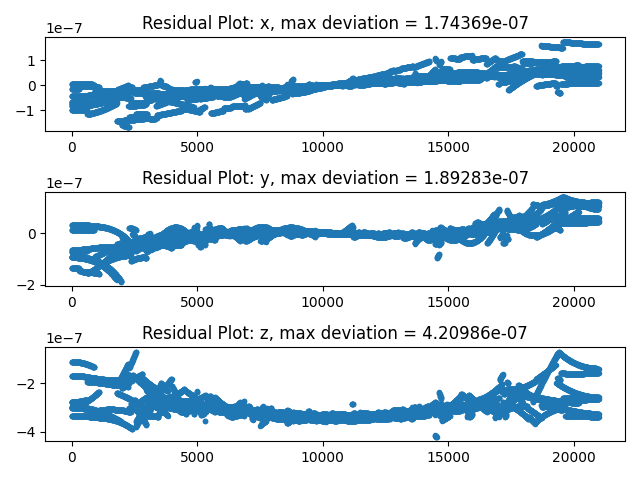

In [334]:
plt.close()
fig, ax = plt.subplots(3, 1)


ax[0].plot((ΔBx - Bx_comsol)/B0, ".")
ax[0].set_title(f"Residual Plot: x, max deviation = {max(np.abs(ΔBx - Bx_comsol)/B0):3g}")

ax[1].plot((ΔBy - By_comsol)/B0, ".")
ax[1].set_title(f"Residual Plot: y, max deviation = {max(np.abs(ΔBy - By_comsol)/B0):3g}")

ax[2].plot((ΔBz - Bz_comsol)/B0, ".")
ax[2].set_title(f"Residual Plot: z, max deviation = {max(np.abs(ΔBz - Bz_comsol)/B0):3g}")

plt.tight_layout()
plt.savefig("saved_data/resid.png")
plt.show()


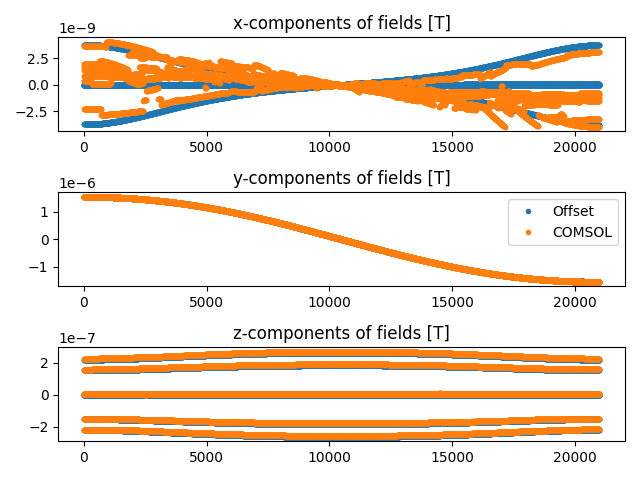

In [333]:

plt.close()
fig, ax = plt.subplots(3, 1)


ax[0].plot(ΔBx, '.', label = "Offset")
ax[0].plot(Bx_comsol, ".", label = "COMSOL")
ax[0].set_title(f"x-components of fields [T]")
# ax[0].legend()

ax[1].plot(ΔBy, '.', label = "Offset")
ax[1].plot(By_comsol, ".", label = "COMSOL")
ax[1].set_title(f"y-components of fields [T]")
ax[1].legend()

ax[2].plot(ΔBz, '.', label = "Offset")
ax[2].plot(Bz_comsol, ".", label = "COMSOL")
ax[2].set_title(f"z-components of fields [T]")
# ax[2].legend()

plt.tight_layout()
plt.savefig("saved_data/field_comp.png")
plt.show()

In [302]:
radial_offset

np.float64(0.24859813084112148)

Notes: 54 coils, 25 cm inside

δx = 1.976e-06

δy = 1.032e-06 (1 part in a million)

δz = 3.323e-06 (3 ppm)


108 coils, 12 cm outside, ends ~flush

δx = 6.232e-07

δy = 9.120e-06

δz = 2.348e-06

108 coils, 12cm outside, ends 12cm out has worse results

